# HW 8 -- Ryan Ermovick

# Level 1 Header for Personal Project

## Data Creation

### Item 1 Paragraph

The data aquisition process for this project mainly entiled gathering data from the movie lens dataset (32 million record version). The files were then downloaded and unpacked. To start, the movies and the ratings files were split up. The movies file became mov and only contains information on movies. The users file has a unique row for each user. Then the users file was supplemented with synthetic data to mimic their jobs, salary, and age. The ratings data table became rat and has ratings from all the users. Finally, another datatable was created that describes users watching history.

In [ ]:
import pandas as pd

First Table is just the ratings

In [ ]:
#load the ratings csv
rat = pd.read_csv("ratings.csv")

Second table is all about each user. This is a synthetic data table.

In [ ]:
#getting unique users
users = pd.DataFrame(rat['userId'].unique(), columns=['userId'])


In [ ]:
import numpy as np
import pandas as pd

# List of common jobs
common_jobs = [
    "Retail Salesperson",
    "Farmer / Agricultural Worker",
    "Cashier",
    "Teacher",
    "Office Clerk / Administrative Assistant",
    "Factory / Manufacturing Worker",
    "Waiter / Waitress / Food Service Worker",
    "Driver (Truck, Taxi, Delivery)",
    "Construction Worker / Laborer",
    "Nurse / Healthcare Worker",
    "Software / IT Professional",
    "Customer Service Representative",
    "Cleaner / Janitor / Housekeeper",
    "Security Guard",
    "Accountant / Bookkeeper",
    "Electrician / Technician",
    "Chef / Cook",
    "Lawyer / Legal Professional",
    "Engineer (Civil, Mechanical, Electrical)",
    "Medical Doctor / Physician"
]

# Create a NumPy random generator
rng = np.random.default_rng()

# Function to generate random jobs using NumPy
def rand_job(size):
    indices = rng.integers(low=0, high=len(common_jobs), size=size)
    return [common_jobs[i] for i in indices]

# Example: add a random job column to your users table
users['job'] = rand_job(len(users))

# Check the result
print(users.head())

   userId                                      job
0       1                Nurse / Healthcare Worker
1       2  Waiter / Waitress / Food Service Worker
2       3               Medical Doctor / Physician
3       4            Construction Worker / Laborer
4       5                  Accountant / Bookkeeper


In [ ]:
# age
import numpy as np
import pandas as pd

# Create a NumPy random generator
rng = np.random.default_rng()

# Function to generate random ages between 8 and 92
def rand_age(size):
    return rng.integers(low=18, high=93, size=size)  # high is exclusive

# Example: add a random age column to your users table
users['age'] = rand_age(len(users))

# Check the result
print(users.head())

   userId                                      job  age
0       1                Nurse / Healthcare Worker   44
1       2  Waiter / Waitress / Food Service Worker   27
2       3               Medical Doctor / Physician   53
3       4            Construction Worker / Laborer   30
4       5                  Accountant / Bookkeeper   88


In [ ]:
import numpy as np

# Map each job to a typical average salary
job_salary_map = {
    "Retail Salesperson": 30000,
    "Farmer / Agricultural Worker": 32000,
    "Cashier": 28000,
    "Teacher": 45000,
    "Office Clerk / Administrative Assistant": 35000,
    "Factory / Manufacturing Worker": 38000,
    "Waiter / Waitress / Food Service Worker": 25000,
    "Driver (Truck, Taxi, Delivery)": 42000,
    "Construction Worker / Laborer": 40000,
    "Nurse / Healthcare Worker": 55000,
    "Software / IT Professional": 100000,
    "Customer Service Representative": 36000,
    "Cleaner / Janitor / Housekeeper": 28000,
    "Security Guard": 30000,
    "Accountant / Bookkeeper": 55000,
    "Electrician / Technician": 50000,
    "Chef / Cook": 38000,
    "Lawyer / Legal Professional": 90000,
    "Engineer (Civil, Mechanical, Electrical)": 85000,
    "Medical Doctor / Physician": 180000
}

# Create NumPy random generator
rng = np.random.default_rng()

def correlated_salary(jobs, sigma=0.3):
    """
    Generate salaries correlated with job type.
    Uses a log-normal distribution centered at the typical average.
    sigma controls spread of variation.
    """
    salaries = []
    for job in jobs:
        avg = job_salary_map.get(job, 40000)  # fallback
        # compute log-mean
        mu = np.log(avg)
        # generate a lognormal around avg
        s = rng.lognormal(mean=mu, sigma=sigma)
        salaries.append(round(s, 2))
    return salaries

# Assign correlated salaries
users['salary'] = correlated_salary(users['job'].tolist())

print(users[['userId','job','salary']].head())

   userId                                      job     salary
0       1                Nurse / Healthcare Worker   59652.03
1       2  Waiter / Waitress / Food Service Worker   29159.57
2       3               Medical Doctor / Physician  176085.05
3       4            Construction Worker / Laborer   42356.66
4       5                  Accountant / Bookkeeper   60152.20


In [ ]:
users

,userId,job,age,salary
0,1,Nurse / Healthcare Worker,44,59652.03
1,2,Waiter / Waitress / Food Service Worker,27,29159.57
2,3,Medical Doctor / Physician,53,176085.05
3,4,Construction Worker / Laborer,30,42356.66
4,5,Accountant / Bookkeeper,88,60152.20
...,...,...,...,...
200943,200944,Construction Worker / Laborer,29,44542.28
200944,200945,Waiter / Waitress / Food Service Worker,70,26660.20
200945,200946,"Engineer (Civil, Mechanical, Electrical)",39,97027.31
200946,200947,Customer Service Representative,61,29301.13


This table is all about the individual movies and some characteristics.

In [ ]:
#reading in the movies dataset
mov = pd.read_csv("movies.csv")

In [ ]:
#cleaning and transformation of the dataset
# extract year
mov['year'] = mov['title'].str.extract(r'\((\d{4})\)$')

# convert to integer (optional)
mov['year'] = mov['year'].astype('Int64')

# remove year from title (optional)
mov['title'] = mov['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)

# one-hot encode genres
genres_dummies = mov['genres'].str.get_dummies(sep='|')

# join back to dataframe
mov = pd.concat([mov, genres_dummies], axis=1)

#drop genres column
mov = mov.drop(columns=['genres'])

Finally, the fourth table is about user interactions (NOT reviews with the movie)

In [ ]:
import numpy as np
import pandas as pd

rng = np.random.default_rng()

# Only consider users who have watched at least one movie
users_with_ratings = rat['userId'].unique()

# Count movies watched per user
user_counts = rat.groupby('userId')['movieId'].count()
# Average rating per user
user_avg = rat.groupby('userId')['rating'].mean()

# Merge counts and averages into one table
watch_history = pd.DataFrame({
    'userId': user_counts.index,
    'num_movies_watched': user_counts.values,
    'avg_rating': user_avg.values
})

# Simulate total minutes watched (80–120 min per movie)
avg_movie_length = rng.integers(80, 121, size=len(watch_history))
watch_history['total_minutes_watched'] = (watch_history['num_movies_watched'] * avg_movie_length).astype(int)

print(watch_history.head())

   userId  num_movies_watched  avg_rating  total_minutes_watched
0       1                 141    3.531915                  12267
1       2                  52    4.269231                   4836
2       3                 147    3.588435                  12789
3       4                  27    2.629630                   2646
4       5                  33    3.272727                   3168


### Bias Identification

For all of the gathered data, there is some room for bias to occur. All of the ratings came from the movie lens dataset, and were provided by actual users. Bias could have come from people intentionally rating a movie high or low (love/hate the movie) or not including all movie watchers. For the synthetic data, bias could have come from not having random data or not accurately representing the human population. There is not room for bias in the user watching history table as that was just calculated data.

### Bias Mitigation

To combat the bias of possibly not including enough users, a dataset of more than 32 million reviews was used. For the synthetic data, care was taken to ensure that the numbers created were not totally random. Research was done as to what the top jobs are in the world and what their mean salaries were. This way the data here is representative of the global population. Finally, as stated before, there is not room for bias in the user watching history table as it is just calculated data.

### Rationale

I decided to make a synthetic data table because an older version of this dataset had such characteristics about the users. It seemed that it would add an extra level of complexity to the data, so I decided to recreate it, despite knowing that it might cause bias down the line. I also decided to create a calculated data table because I think that these would be good statistics to help with a reccomendation model.

## Metadata

https://grouplens.org/datasets/movielens/


### Schema
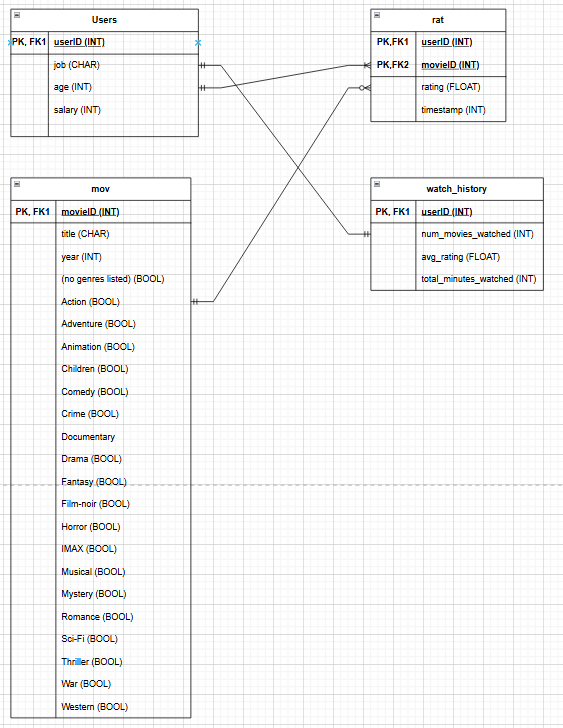!

### Data
| Data Table | Description | Link |
| :--- | :--- | :--- |  
| Users | Data on each user and their lifestyle | https://myuva-my.sharepoint.com/:u:/g/personal/jph4dg_virginia_edu/IQC_xbzgFSKXR4B8LNuIMLNMASOhKf_ur-fGPIIZVRA0VQ8?e=CXeMEk |
| mov | The movie and its attributes | https://myuva-my.sharepoint.com/:u:/g/personal/jph4dg_virginia_edu/IQBH4NaMFDv0SI99m0olBM4jAcpSeeKkrdquO10eR72xM68?e=riHAZp |
| rat | The rating for each movie and who made it | https://myuva-my.sharepoint.com/:u:/g/personal/jph4dg_virginia_edu/IQBci4BDwolUT7BPSJX9j9d0AYhQcVdx_e2T6thQRQXEqq0?e=uzndcu |
| watch_history | The watch history of each user | https://myuva-my.sharepoint.com/:u:/g/personal/jph4dg_virginia_edu/IQBiOYNjkfwmTIoGh8txSFexAUrb-X5NKhX7WBdxmjqTS8M?e=byNohj |

### Data Dictionary

Users
| Name | Datatype | Description | Example |
| :--- | :--- | :--- | :--- |
| userID | INT | Inique user identification code | 1 |
| job | INT | The job of the user | Customer Sales Representative |
| age | INT | The age of the user | 25 |
| salary | CHAR | The salary of the user | 33000 |

Rat
| Name | Datatype | Description | Example |
| :--- | :--- | :--- | :--- |
| userID | INT | The unique ID of the user | 1 |
| movieID | INT | The unique ID of the movie | 1 |
| rating | FLOAT | The rating the user gave the movie | 5.0 |
| timestamp | FLOAT | The time at which the review was made | 944249077.0 |

watch_history
| Name | Datatype | Description | Example |
| :--- | :--- | :--- | :--- |
| userID | INT | The unique ID of the user | 1 |
| num_movies_watched | INT | The number of movies that user has watched | 141 |
| avg_rating | FLOAT | The average rating that a user gives a movie | 3.53 |
| total_minutes_watched | INT | The total minutes this user has spent watching movies that they have reviewed | 16074 |

mov

| Name | Datatype | Description | Example |
| :--- | :--- | :--- | :--- |
| movieID | INT | The unique ID of the movie | 1 |
| title | CHAR | The title of the movie | Toy Story |
| year | INT | The year the movie was released | 2000 |
| (no genres listed) | BOOL | If the movie did not have a genre listed | 1 |
| Action | BOOL | If the movie was Action genre | 1 |
| Adventure | BOOL | If the movie was Adventure genre | 0 |
| Animation | BOOL | If the movie was Animated | 1 |
| Children | BOOL | If the movie was Children genre | 0 |
| Comedy | BOOL | If the movie was Comedy genre | 1 |
| Crime | BOOL | If the movie was Crime genre | 1 |
| Documentary | BOOL | If the movie was Documentary genre | 1 |
| Drama | BOOL | If the movie was Drama genre | 1 |
| Fantasy | BOOL | If the movie was Fantasy genre | 0 |
| Film-noir | BOOL | If the movie was Film-noir genre | 1 |
| Horror | BOOL | If the movie was Horror genre | 1 |
| IMAX | BOOL | If the movie was IMAX genre | 1 |
| Musical | BOOL | If the movie was Musical genre | 0 |
| Mystery | BOOL | If the movie was Mystery genre | 0 |
| Romance | BOOL | If the movie was Romance genre | 0 |
| Sci-Fi | BOOL | If the movie was Sci-Fi genre | 1 |
| Thriller | BOOL | If the movie was Thriller genre | 1 |
| War | BOOL | If the movie was War genre | 0 |
| Western | BOOL | If the movie was Western genre | 1 |



### Data Dictionary

There are multiple numerical columns that have no uncertainty associated with them as they are just identifiers. In the mov datatable, the year column has no uncertainty as it is just the year the movie was released. The watch history has uncertainty for the avg_rating, as this was a calculated number and some numbers might be rounded off. As such, the uncertainty for this is +- 0.000005 rating points. The total minutes watched and movies watched are both sums and do not have any uncertainty. In the rating table, there is no uncertainty in the rating column because these are just user inputted values. In the users datatable, there is uncertainty in the age as this was a synthetic number generated. Any uncertainty is around if it accurately reflects the population of movie watchers. The uncertainty is +-1 year. The uncertainty for the salary is +-$1,000 as this is also a synthetically generated number.

## Pipeline Check

Here is the code to find the average rating by job, category, and age.

In [ ]:
import duckdb
import pandas as pd

# Connect to in-memory DuckDB
con = duckdb.connect(database=':memory:')

# Register your tables
con.register('users', users)
con.register('movies', mov)
con.register('ratings', rat)
con.register('watch_history', watch_history)

# Multi-dimensional aggregation query
query = """
SELECT
    u.job,
    -- Get all genres dynamically by one-hot columns
    CASE
        WHEN m.Comedy = 1 THEN 'Comedy'
        WHEN m.Drama = 1 THEN 'Drama'
        WHEN m.Action = 1 THEN 'Action'
        WHEN m.Adventure = 1 THEN 'Adventure'
        ELSE 'Other'
    END AS genre,
    CASE
        WHEN u.age < 30 THEN '<30'
        WHEN u.age < 50 THEN '30-49'
        ELSE '50+'
    END AS age_group,
    AVG(r.rating) AS avg_rating,
    COUNT(*) AS num_ratings
FROM ratings r
JOIN users u ON r.userId = u.userId
JOIN movies m ON r.movieId = m.movieId
JOIN watch_history w ON u.userId = w.userId
WHERE w.total_minutes_watched > 500
GROUP BY u.job, genre, age_group
ORDER BY u.job, genre, age_group
"""

# Execute query
multi_dim_results = con.execute(query).fetchdf()

# Print the first 20 rows of the multi-dimensional aggregation
print("Average ratings by Job × Genre × Age Group (for users with >500 min watched):\n")
print(multi_dim_results.head(20))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Average ratings by Job × Genre × Age Group (for users with >500 min watched):

                        job      genre age_group  avg_rating  num_ratings
0   Accountant / Bookkeeper     Action     30-49    3.451886        76714
1   Accountant / Bookkeeper     Action       50+    3.454198       163627
2   Accountant / Bookkeeper     Action       <30    3.468037        43409
3   Accountant / Bookkeeper  Adventure     30-49    3.573047        13457
4   Accountant / Bookkeeper  Adventure       50+    3.592449        27480
5   Accountant / Bookkeeper  Adventure       <30    3.606127         7312
6   Accountant / Bookkeeper     Comedy     30-49    3.409013       154413
7   Accountant / Bookkeeper     Comedy       50+    3.424550       330250
8   Accountant / Bookkeeper     Comedy       <30    3.434042        83333
9   Accountant / Bookkeeper      Drama     30-49    3.686021       152803
10  Accountant / Bookkeeper      Drama       50+    3.688361       324866
11  Accountant / Bookkeeper      

In [ ]:
#users, mov, rat, watch_history

# Save all tables as Parquet files
users.to_parquet('users.parquet', index=False)
rat.to_parquet('rat.parquet', index=False)
mov.to_parquet('mov.parquet', index=False)
watch_history.to_parquet('watch_history.parquet', index=False)

In [ ]:
watch_history.head()

,userId,num_movies_watched,avg_rating,total_minutes_watched
0,1,141,3.531915,12267
1,2,52,4.269231,4836
2,3,147,3.588435,12789
3,4,27,2.629630,2646
4,5,33,3.272727,3168
